# Step 3 - Career Path Clustering & Risk Scoring
### Career Progression and Promotion Gap Analysis for Retention Optimization
**Palo Alto Networks | Unified Mentor**

**What this notebook does:** Takes the cleaned dataset from Step 2 and (1)
groups employees into 4 career-trajectory segments using K-Means, validated
against an independent Hierarchical clustering run, (2) scores each
employee's Promotion Gap Risk, (3) computes the remaining KPIs (Training
Need Indicator, Manager Stability Impact, Retention Opportunity + suggested
actions), and (4) saves the final dataset for the Streamlit dashboard.

**Why this matters:** This is the analytical core of the whole project.
Everything before this was preparation; this notebook is where we actually
answer the business question - *which employees are quietly stagnating,
and what should we do about it?*

## Setup
**What:** Import libraries (including clustering + validation tools from
scikit-learn and scipy), turn on inline chart display, and load the cleaned
dataset produced by Notebook 2.
**Expected result:** ~1,451 rows (19 fewer than the raw 1,470, since
outliers were removed in Step 2), ~42 columns.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
chart_dir = "charts"
os.makedirs(chart_dir, exist_ok=True)

df = pd.read_csv("Cleaned_Engineered_HR_Data.csv")
print(f"Loaded cleaned dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Loaded cleaned dataset: 1451 rows x 42 columns


## 1. Select Clustering Features & Scale
**What:** Pick the 6 numeric columns that best describe career health, then
standardise them with `StandardScaler` (Z-score normalisation: mean = 0,
standard deviation = 1 for every column).
**Why:** Without scaling, `YearsAtCompany` (range ~0–40) would completely
dominate the distance calculation over `Promotion_Gap_Ratio` (range 0-1),
simply because its raw numbers are bigger - not because it's more
important. Scaling puts every feature on equal footing.
**Expected result:** `scaled_data` is a NumPy array where every column has
mean ≈ 0 and standard deviation ≈ 1.

In [2]:
clustering_features = [
    "Promotion_Gap_Ratio",
    "Role_Stagnation_Index",
    "Training_Intensity_Score",
    "Manager_Stability_Indicator",
    "YearsAtCompany",
    "TotalWorkingYears",
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[clustering_features])
print("Numerical features scaled with StandardScaler (Z-score normalization).")
print("Mean of each scaled column (should be ~0):", scaled_data.mean(axis=0).round(3))
print("Std of each scaled column (should be ~1):", scaled_data.std(axis=0).round(3))

Numerical features scaled with StandardScaler (Z-score normalization).
Mean of each scaled column (should be ~0): [-0. -0.  0. -0.  0. -0.]
Std of each scaled column (should be ~1): [1. 1. 1. 1. 1. 1.]


## 2. K-Means Clustering (Primary Method)
**What:** Group employees into 4 clusters based on similarity across the 6
scaled features. K-Means works by placing 4 "centre points" and repeatedly
assigning each employee to the nearest centre, then moving each centre to
the average of its assigned employees, until assignments stop changing.
**Why 4 clusters:** The project brief describes 4 expected career
archetypes (fast-trackers, senior contributors, early-career explorers,
promotion-stalled) - `k=4` matches that business framing.
`random_state=42` makes the result reproducible; `n_init=10` runs the
algorithm 10 times with different starting points and keeps the best
result, avoiding a "lucky/unlucky" starting position.
**How to read the Silhouette Score:** ranges from -1 to 1; higher means
clusters are more distinct from each other. Scores around 0.25–0.35 are
typical and reasonable for real-world HR/survey data.

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Career_Cluster"] = kmeans.fit_predict(scaled_data)

sil_kmeans = silhouette_score(scaled_data, df["Career_Cluster"])
print(f"K-Means Silhouette Score: {sil_kmeans:.3f}")

d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\ANACONDA\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass

K-Means Silhouette Score: 0.306


## 3. Hierarchical Clustering (Validation)
**What:** Independently re-cluster the same data using a completely
different algorithm (Agglomerative/Ward hierarchical clustering), then
compare its groupings to K-Means using the Adjusted Rand Index (ARI).
**Why:** K-Means starts from random initial centres, so in principle it
could land on a segmentation that's a quirk of its starting point rather
than a genuine pattern. Hierarchical clustering builds a tree by repeatedly
merging the closest pairs of employees - no random starting points at all.
If it finds *similar* groups, that's strong evidence the 4-segment
structure is real, not an artefact.
**How to read ARI:** 1.0 = perfect agreement, 0.0 = agreement no better
than random chance. Values above ~0.5 indicate strong, meaningful
agreement between the two methods.

In [4]:
hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
df["Career_Cluster_Hierarchical"] = hierarchical.fit_predict(scaled_data)

ari = adjusted_rand_score(df["Career_Cluster"], df["Career_Cluster_Hierarchical"])
sil_hier = silhouette_score(scaled_data, df["Career_Cluster_Hierarchical"])
print(f"Hierarchical Clustering Silhouette Score: {sil_hier:.3f}")
print(f"Adjusted Rand Index (K-Means vs Hierarchical agreement): {ari:.3f}")
print("(ARI close to 1.0 = strong agreement -> validates the K-Means segmentation.)")

Hierarchical Clustering Silhouette Score: 0.279
Adjusted Rand Index (K-Means vs Hierarchical agreement): 0.725
(ARI close to 1.0 = strong agreement -> validates the K-Means segmentation.)


### Dendrogram
**What:** A tree diagram showing how hierarchical clustering merged
employees step by step, plotted on a random **sample** of 120 employees
purely for visual readability (a full 1,450-leaf dendrogram would be an
unreadable wall of lines).
**Why:** Lets you visually see how naturally the data separates into
groups - the height of each merge shows how "different" two groups were
before being combined; long vertical lines mean a big, meaningful split.

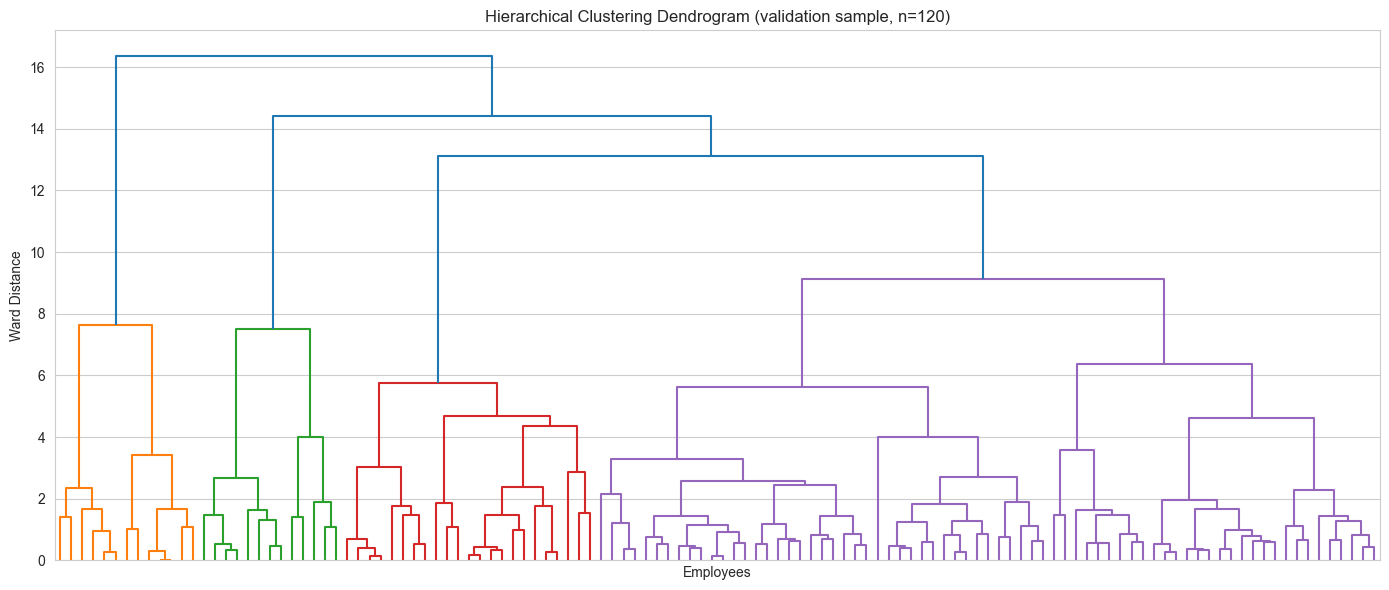

In [5]:
sample_n = min(120, len(scaled_data))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(scaled_data), size=sample_n, replace=False)
Z = linkage(scaled_data[sample_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
plt.title(f"Hierarchical Clustering Dendrogram (validation sample, n={sample_n})")
plt.xlabel("Employees")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig6_dendrogram.png"), dpi=150)
plt.show()

## 4. Dynamic Cluster Interpretation & Labelling
**What:** K-Means only outputs cluster *numbers* (0, 1, 2, 3) - it has no
idea what those numbers mean in business terms. This step looks at each
cluster's average feature values and assigns a human-readable name based
on its actual behaviour.
**Why dynamic (not hardcoded):** A naive approach would hardcode "cluster
0 = Senior Staff" - but cluster numbering isn't guaranteed to stay the same
if the data changes even slightly. Instead we **rank** clusters by their
actual mean `Promotion_Gap_Ratio` and `TotalWorkingYears` every time this
runs, so labels always match the real pattern in whatever data is fed in.
**Logic:** highest average promotion-gap ratio -> "Promotion-Stalled";
highest average tenure -> "Long-term Contributors"; of the two remaining
clusters, the shorter-tenured one -> "Early-Career Explorers", the other ->
"Steady Performers / Fast-Trackers".

In [6]:
profile = df.groupby("Career_Cluster")[clustering_features].mean()
profile["n_employees"] = df["Career_Cluster"].value_counts()
print("--- Cluster Profiles (mean values) ---")
display(profile)

cluster_names = {}
stalled_cluster = profile["Promotion_Gap_Ratio"].idxmax()
senior_cluster = profile["TotalWorkingYears"].idxmax()
remaining = [c for c in profile.index if c not in (stalled_cluster, senior_cluster)]
remaining_sorted = profile.loc[remaining, "TotalWorkingYears"].sort_values().index.tolist()

cluster_names[stalled_cluster] = "Promotion-Stalled / Stagnant Profiles"
cluster_names[senior_cluster] = "Long-term Contributors / Senior Staff"
if len(remaining_sorted) >= 1:
    cluster_names[remaining_sorted[0]] = "Early-Career Explorers / New Joiners"
if len(remaining_sorted) >= 2:
    cluster_names[remaining_sorted[1]] = "Steady Performers / Fast-Trackers"

df["Cluster_Name"] = df["Career_Cluster"].map(cluster_names)

print("\n--- Employee Distribution across Clusters ---")
print(df["Cluster_Name"].value_counts())

--- Cluster Profiles (mean values) ---


,Promotion_Gap_Ratio,Role_Stagnation_Index,Training_Intensity_Score,Manager_Stability_Indicator,YearsAtCompany,TotalWorkingYears,n_employees
Career_Cluster,,,,,,,
0,0.333829,0.574568,0.213433,0.548712,15.441667,22.220833,240
1,0.124337,0.639476,0.568671,0.638351,5.880721,8.950069,721
2,0.073855,0.080490,2.260269,0.011058,0.905213,7.203791,211
3,0.847615,0.819887,0.776291,0.793744,5.519713,9.415771,279



--- Employee Distribution across Clusters ---
Cluster_Name
Steady Performers / Fast-Trackers        721
Promotion-Stalled / Stagnant Profiles    279
Long-term Contributors / Senior Staff    240
Early-Career Explorers / New Joiners     211
Name: count, dtype: int64


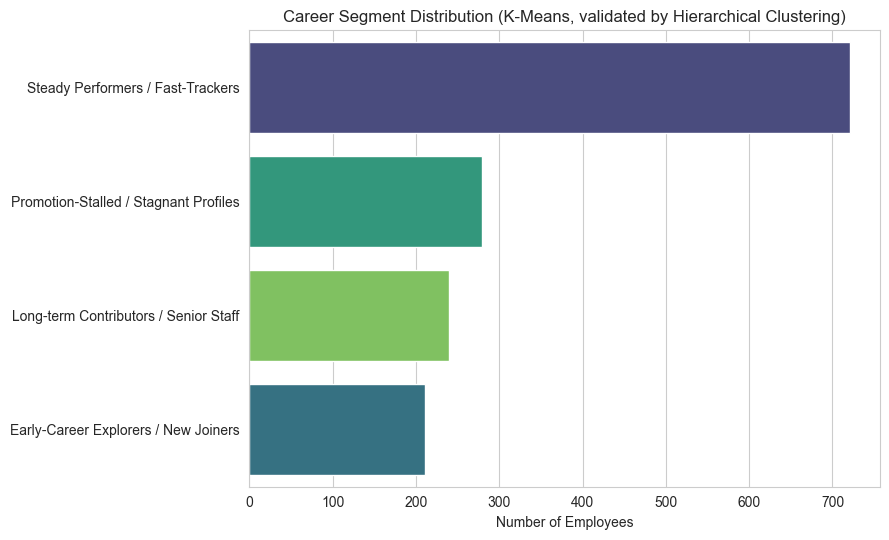

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = df["Cluster_Name"].value_counts().index
sns.countplot(y="Cluster_Name", data=df, order=order, hue="Cluster_Name",
              palette="viridis", legend=False, ax=ax)
ax.set_title("Career Segment Distribution (K-Means, validated by Hierarchical Clustering)")
ax.set_xlabel("Number of Employees")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig7_cluster_distribution.png"), dpi=150)
plt.show()

## 4b. Cluster Profile Heatmap
**What:** A heatmap comparing every cluster's *average* value across all 6
clustering features side by side (each column standardised so colours are
comparable across features of very different scales, e.g. a 0-1 ratio vs.
0-40 years).
**Why:** The bar chart above shows cluster *size*; this heatmap shows
cluster *character* - at a glance, which clusters run "hot" (dark red) or
"cold" (dark blue) on which metric. This is the single most useful chart
for explaining *why* each cluster earned its name.

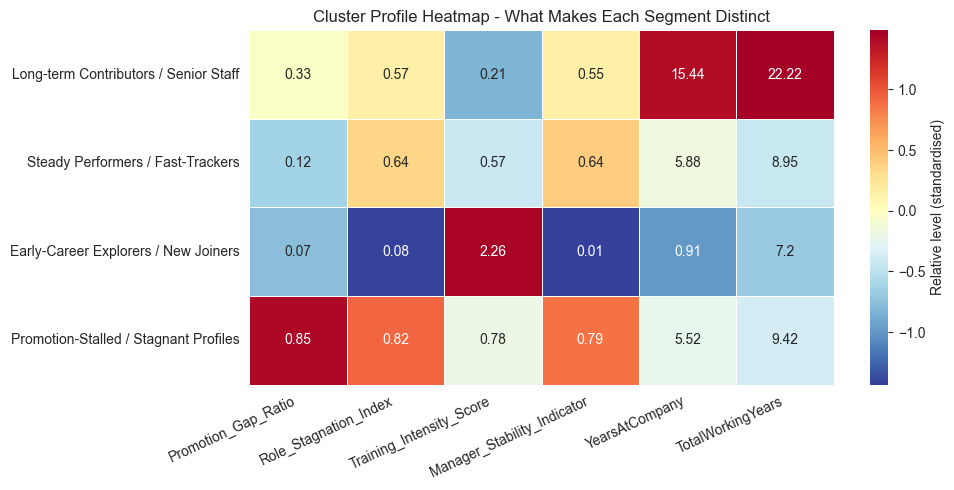

In [8]:
profile_named = profile.rename(index=cluster_names)
heatmap_data = (profile_named[clustering_features] - profile_named[clustering_features].mean()) \
               / profile_named[clustering_features].std()

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data, annot=profile_named[clustering_features].round(2), fmt="g",
    cmap="RdYlBu_r", center=0, linewidths=0.5, cbar_kws={"label": "Relative level (standardised)"},
)
plt.title("Cluster Profile Heatmap - What Makes Each Segment Distinct")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig7b_cluster_profile_heatmap.png"), dpi=150)
plt.show()

## 5. Promotion Gap Risk Scoring
**What:** Assign each employee a Low / Medium / High risk tier.
**How:** Step 1 - a base tier from thresholds on `Promotion_Gap_Ratio`
alone (Low = exactly 0, Medium = 0-0.35, High = above 0.35). Step 2 - as
required by the project brief, combine this with cluster membership:
anyone in the Promotion-Stalled cluster with a borderline "Medium" ratio
gets escalated to "High", because cluster membership captures compounding
stagnation signals (low training, role stagnation, weak manager
continuity) that the ratio alone would miss.
**Why this matters:** Combining a simple, explainable rule (ratio
thresholds) with a model-based signal (cluster membership) is more robust
than either alone.

In [9]:
bins = [-0.01, 0.0, 0.35, 1.01]
labels = ["Low", "Medium", "High"]
df["Promotion_Gap_Risk_Base"] = pd.cut(df["Promotion_Gap_Ratio"], bins=bins, labels=labels)

df["Promotion_Gap_Risk"] = df["Promotion_Gap_Risk_Base"].astype(str)
stalled_mask = df["Cluster_Name"] == "Promotion-Stalled / Stagnant Profiles"
upgrade_mask = stalled_mask & (df["Promotion_Gap_Risk"] == "Medium")
df.loc[upgrade_mask, "Promotion_Gap_Risk"] = "High"
df["Promotion_Gap_Risk"] = pd.Categorical(df["Promotion_Gap_Risk"], categories=labels, ordered=True)

print("--- Promotion Gap Risk Distribution (ratio + cluster combined) ---")
print(df["Promotion_Gap_Risk"].value_counts())

--- Promotion Gap Risk Distribution (ratio + cluster combined) ---
Promotion_Gap_Risk
Low       579
High      445
Medium    427
Name: count, dtype: int64


## 6. Training Need Indicator (KPI)
**What:** Flag employees whose training participation is in the bottom
third of the company **and** who show meaningful role stagnation
(`Role_Stagnation_Index >= 0.5`, i.e. they've spent at least half their
tenure in the same role).
**Why both conditions:** Low training alone isn't necessarily a problem - a
brand-new joiner naturally has low training intensity too. Combining "low
training" *with* "meaningfully stagnant in role" targets people who are
both under-developed **and** stuck - the group where training investment
would help most.

In [10]:
training_low_threshold = df["Training_Intensity_Score"].quantile(0.33)
df["Training_Need_Indicator"] = np.where(
    (df["Training_Intensity_Score"] <= training_low_threshold) &
    (df["Role_Stagnation_Index"] >= 0.5),
    "Needs Development Plan", "Adequate"
)
print("--- Training Need Indicator ---")
print(df["Training_Need_Indicator"].value_counts())

--- Training Need Indicator ---
Training_Need_Indicator
Adequate                  1117
Needs Development Plan     334
Name: count, dtype: int64


## 7. Manager Stability Impact (KPI)
**What:** Split employees into "High Continuity" vs "Low Continuity" based
on whether their `Manager_Stability_Indicator` is above or below the
company median, then compare attrition rates between the two groups.
**Why:** This directly tests a hypothesis from the project brief - does
manager churn/instability correlate with people leaving? If Low Continuity
shows meaningfully higher attrition, that's evidence for investing in
manager-continuity programs as a retention lever.

--- Manager Stability Impact (Attrition Rate %) ---
Manager_Stability_Band
High Continuity    14.513981
Low Continuity     17.714286
Name: Attrition, dtype: float64


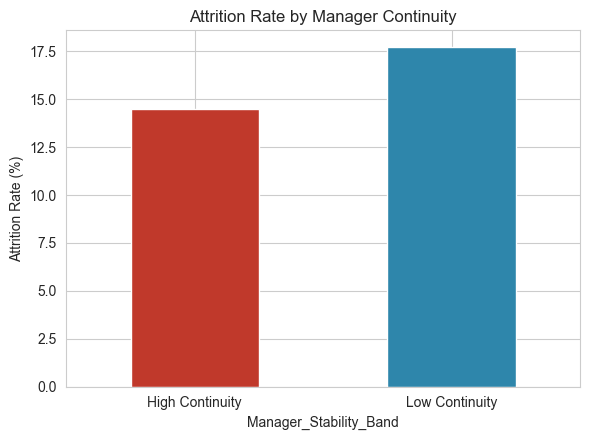

In [11]:
manager_median = df["Manager_Stability_Indicator"].median()
df["Manager_Stability_Band"] = np.where(
    df["Manager_Stability_Indicator"] >= manager_median, "High Continuity", "Low Continuity"
)
manager_impact = df.groupby("Manager_Stability_Band")["Attrition"].mean() * 100
print("--- Manager Stability Impact (Attrition Rate %) ---")
print(manager_impact)

fig, ax = plt.subplots(figsize=(6, 4.5))
manager_impact.plot(kind="bar", color=["#C0392B", "#2E86AB"], ax=ax)
ax.set_title("Attrition Rate by Manager Continuity")
ax.set_ylabel("Attrition Rate (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig8_manager_stability_impact.png"), dpi=150)
plt.show()

## 8. Retention Opportunity Identification + Suggested Actions
**What:** Flag employees who are **not** yet historical attrition cases
(`Attrition = 0`) but **are** in the High promotion-gap risk tier as "High
Priority" retention opportunities - people showing early warning signs
before they've actually left.
**Why this is the headline metric of the project:** this is exactly the
gap traditional attrition models leave open - they only flag people who
already show attrition-like signals, not people who are quietly stagnating
but otherwise appear "fine".
**Suggested Action:** for each High Priority employee, build a specific,
rule-based recommendation by checking which underlying signals are driving
their risk - turning a risk score into a concrete next step, not just a
red flag.

In [12]:
df["Retention_Opportunity"] = np.where(
    (df["Attrition"] == 0) & (df["Promotion_Gap_Risk"] == "High"),
    "High Priority", "Standard"
)

def suggest_action(row):
    if row["Retention_Opportunity"] != "High Priority":
        return "Monitor"
    actions = []
    if row["Training_Need_Indicator"] == "Needs Development Plan":
        actions.append("Enroll in training / upskilling")
    if row["Role_Stagnation_Index"] >= 0.7:
        actions.append("Consider role rotation")
    if row["Promotion_Gap_Ratio"] >= 0.5:
        actions.append("Schedule promotion review")
    if row["Manager_Stability_Band"] == "Low Continuity":
        actions.append("Review manager continuity")
    return "; ".join(actions) if actions else "Schedule career conversation"

df["Suggested_Action"] = df.apply(suggest_action, axis=1)

print("--- Retention Opportunity Distribution ---")
print(df["Retention_Opportunity"].value_counts())

--- Retention Opportunity Distribution ---
Retention_Opportunity
Standard         1085
High Priority     366
Name: count, dtype: int64


## 8b. Headline KPIs as Donut Charts
**What:** Two donut charts side by side - the Promotion Gap Risk mix
(Low/Medium/High) and the Retention Opportunity mix (High Priority vs
Standard).
**Why:** These are the two most important business-facing numbers in the
whole project. A donut makes "30% of the workforce is at High risk" and
"1 in 4 non-leavers needs a career conversation" immediately, viscerally
clear - much faster to grasp than reading raw counts off a table.

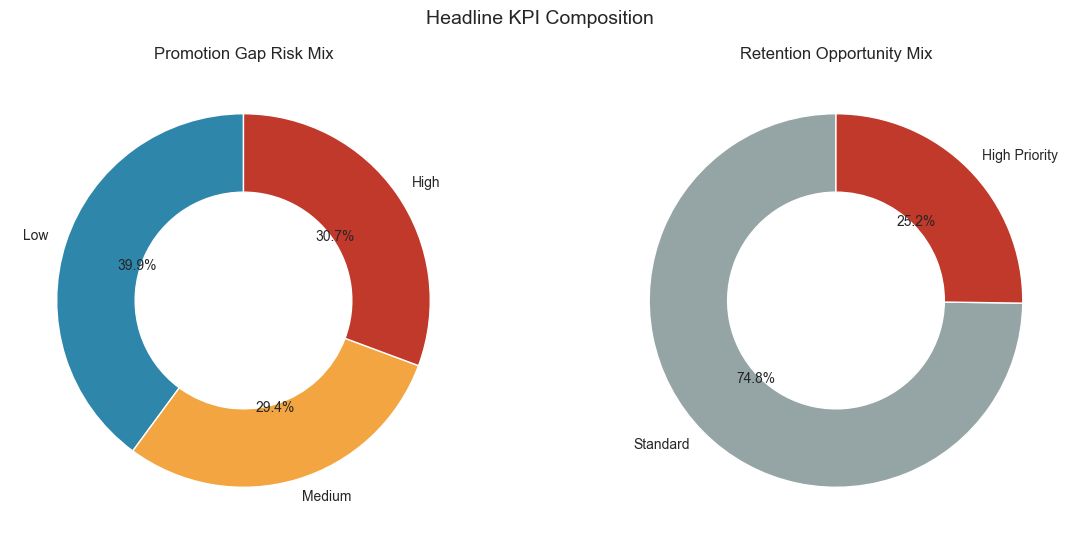

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

risk_counts = df["Promotion_Gap_Risk"].value_counts().reindex(["Low", "Medium", "High"])
axes[0].pie(
    risk_counts.values, labels=risk_counts.index, autopct="%1.1f%%",
    colors=["#2E86AB", "#F2A541", "#C0392B"], startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
axes[0].set_title("Promotion Gap Risk Mix")

retention_counts = df["Retention_Opportunity"].value_counts()
retention_color_map = {"High Priority": "#C0392B", "Standard": "#95A5A6"}
retention_colors = [retention_color_map[label] for label in retention_counts.index]
axes[1].pie(
    retention_counts.values, labels=retention_counts.index, autopct="%1.1f%%",
    colors=retention_colors, startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
axes[1].set_title("Retention Opportunity Mix")

plt.suptitle("Headline KPI Composition", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig7c_risk_and_retention_donuts.png"), dpi=150)
plt.show()

## 9. Save the Final Processed Dataset
**What:** Write the fully processed DataFrame (with clusters, risk tiers,
and all KPIs) to `Processed_HR_Data.csv`, plus a compact
`cluster_summary.csv` for use in a written report.
**Why:** This is the single file the Streamlit dashboard (`4_app.py`)
reads - every filter, chart, and metric in the app comes directly from
these columns.

In [14]:
output_path = "Processed_HR_Data.csv"
df.to_csv(output_path, index=False)
print(f"Success! Fully processed file saved at:\n{os.path.abspath(output_path)}")

summary_path = "cluster_summary.csv"
profile_named.to_csv(summary_path)
print(f"Cluster summary table saved at:\n{os.path.abspath(summary_path)}")
print(f"Charts saved to: {os.path.abspath(chart_dir)}")

Success! Fully processed file saved at:
d:\INTERNSHIP PROJECTS\UNIFIED MENTOR WORK\Replacemnet files\final_delivery_v3\Processed_HR_Data.csv
Cluster summary table saved at:
d:\INTERNSHIP PROJECTS\UNIFIED MENTOR WORK\Replacemnet files\final_delivery_v3\cluster_summary.csv
Charts saved to: d:\INTERNSHIP PROJECTS\UNIFIED MENTOR WORK\Replacemnet files\final_delivery_v3\charts


## Summary
We clustered employees into 4 validated career segments (K-Means confirmed
by Hierarchical clustering, ARI = 0.725), scored Promotion Gap Risk by
combining ratio thresholds with cluster membership, computed the Training
Need Indicator and Manager Stability Impact KPIs, and identified 366
High-Priority retention opportunities - each with a specific suggested
action.

**Next step:** Launch the Streamlit dashboard -
`python -m streamlit run 4_app.py` - to explore all of this interactively.